# Exoplanets!

This week we're going to think about exoplanet *habitability*. We’re going to be working with the Exoplanets Archive, a database that tracks every exoplanet detected so far. In the first part of the workbook, you’ll practice working with the database and take a look at different planet properties. Then we’ll make a calculator to find habitable zones for each exoplanet system. 

### background
If you want to read more context about exoplanets and habitable zones, you can take a look at these links:
- [exolanet article](https://exoplanets.nasa.gov/what-is-an-exoplanet/overview/)
- [NASA habitable zone article](https://exoplanets.nasa.gov/search-for-life/habitable-zone/)

### habitable zones
Let's go through the steps of constructing an equation to identify where the habitable zone will be for any given star. Schematically, we're going to try and figure out how far away a planet must be from its host star in order to host life.

1. First, let's remind ourselves what defines the habitable zone. What temperature should a planet's surface be in order to be considered part of the habitable zone?
2. Let's try and figure out how we can calculate the surface temperature of a planet:
    1. Draw a diagram of the host star (with a radius $R_\star$ and temperture $T_\star$) and a planet orbiting that star (with a radius $R_{\rm planet}$ and temperature $T_{\rm planet}$) at a distance $d$.
	2. If the star emits light in all directions with a luminosity (energy/s) $L_\star$, what fraction of that energy will be collected by the planet? This is a purely geometric effect -- try and write an expression for the energy that the planet receives $L_{\rm rec}$. (it might help to think about the area of the planet that is available to collect light)
	3. For simplicity, let's assume that the planet collects all this incident energy and then re-radiates it. When an object emits light like this, we can write the amount of energy it outputs per unit time at its surface as $L = 4\pi R^2\sigma_{\rm SB}T^4$, where $T$ is the object's temperature, $R$ is its radius, and $\sigma_{\rm SB} = 5.67\times 10^{-5}\ {\rm erg\ cm^{-2}\ s^{-1}\ K^{-4}}$ is a constant. *note that because we've expressed $\sigma_{\rm SB}$ in CGS units, this means that $R, T,$ and $L$ must be in CGS units as well (${\rm cm,\ K,\ erg/s}$, respectively).*  Using this equation, solve for the temperature of the planet in terms of the energy that it's received $L_{\rm rec}$.
	4. Combine the expressions from steps 2 and 3 to solve for the temperature of the planet. What does this quantity depend on? Do the dependences make sense?
	5. Invert this expression to solve for the distance of the planet given this temperature. This will come in handy later in the code.


### coding
Ok, enough background and algebra, let's code some of this up! First, let's import the modules we'll need:

In [1]:
# Imports
import numpy as np # this does math
import pandas as pd # this is pandas, which we're going to use to manage our spreadsheet of exoplanet systems
import matplotlib.pyplot as plt # this lets us plot things

## Exoplanet Data -- Practice with Pandas

The NASA exoplanet archive (https://exoplanetarchive.ipac.caltech.edu/) keep track of all of the known exoplanet systems. We'll start by reading in the data from the exoplanet archive into something called a data frame (basically just a spreadsheet that we can use to organize the planet systems and their properties). 

First, go to the exoplanet archive and click on the 'data' tab and then 'planetary systems'. You should see a large table. Each row is a planetary system, and the columns list some of the properties for each system. The file 'exo_archive.csv' is just a downloaded version of the exoplanets archive table. 

To work with the table of exoplanet data, we're going to be using a tool called 'pandas' (https://www.w3schools.com/python/pandas/pandas_intro.asp). The first part of this notebook will give a tutorial on how to use pandas. 

In [2]:
# First, let's read in the data and practice working with a data table
data = pd.read_csv('exo_archive.csv', index_col='pl_name')
data #This displays the table. You can just think of it as a regular spreadsheet, with row and column names. 

,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,pl_refname,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
pl_name,,,,,,,,,,,,,,,,,,,,,
11 Com b,11 Com,1,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,<a refstr=TENG_ET_AL__2023 href=https://ui.ads...,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2023-09-19,2023-08,2023-09-19
11 UMi b,11 UMi,1,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,Published Confirmed,0,<a refstr=STASSUN_ET_AL__2017 href=https://ui....,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-09-04,2017-03,2018-09-06
14 And b,14 And,1,1,1,Radial Velocity,2008,Okayama Astrophysical Observatory,Published Confirmed,0,<a refstr=TENG_ET_AL__2023 href=https://ui.ads...,...,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826,2023-09-19,2023-08,2023-09-19
14 Her b,14 Her,1,1,2,Radial Velocity,2002,W. M. Keck Observatory,Published Confirmed,0,<a refstr=FENG_ET_AL__2022 href=https://ui.ads...,...,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351,2023-06-12,2022-09,2023-06-12
16 Cyg B b,16 Cyg B,1,3,1,Radial Velocity,1996,Multiple Observatories,Published Confirmed,0,<a refstr=STASSUN_ET_AL__2017 href=https://ui....,...,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603,2018-09-04,2017-03,2018-09-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ups And b,ups And,1,2,3,Radial Velocity,1996,Lick Observatory,Published Confirmed,0,<a refstr=CURIEL_ET_AL__2011 href=https://ui.a...,...,-0.023,2.859,0.274,-0.274,3.98687,0.008937,-0.008937,2019-01-28,2011-01,2019-01-31
ups And c,ups And,1,2,3,Radial Velocity,1999,Multiple Observatories,Published Confirmed,0,<a refstr=CURIEL_ET_AL__2011 href=https://ui.a...,...,-0.023,2.859,0.274,-0.274,3.98687,0.008937,-0.008937,2019-01-28,2011-01,2019-01-31
ups And d,ups And,1,2,3,Radial Velocity,1999,Multiple Observatories,Published Confirmed,0,<a refstr=CURIEL_ET_AL__2011 href=https://ui.a...,...,-0.023,2.859,0.274,-0.274,3.98687,0.008937,-0.008937,2019-01-28,2011-01,2019-01-31


In [3]:
data.columns

Index(['hostname', 'default_flag', 'sy_snum', 'sy_pnum', 'discoverymethod',
       'disc_year', 'disc_facility', 'soltype', 'pl_controv_flag',
       'pl_refname', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2',
       'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2',
       'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim',
       'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasse',
       'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj',
       'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov',
       'pl_orbeccen', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim',
       'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt',
       'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname',
       'st_spectype', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim',
       'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass',
       'st_masserr1', 'st_masserr2', 'st_mass

Practice retrieving data from the data frame! The data frame has an index (the planet names) and different columns. The full list of column names and what they mean can be found here: https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html, but we'll point out some of the most important columns in the following cells. We can pull out a single row from the table by specifying an index label (planet name). When doing a row index, we have to put ".loc" to let pandas know we're giving it an index label.

In [4]:
print(data.loc['51 Peg b'])

hostname                    51 Peg
default_flag                     1
sy_snum                          1
sy_pnum                          1
discoverymethod    Radial Velocity
                        ...       
sy_gaiamagerr1            0.002768
sy_gaiamagerr2           -0.002768
rowupdate               2014-05-14
pl_pubdate                 2006-07
releasedate             2014-05-14
Name: 51 Peg b, Length: 95, dtype: object


We can also get a column by specifying a column name (no .loc needed). For example, let's get the list of all masses:

In [5]:
print(data['pl_bmasse']) # pl stands for 'planet' and bmasse refers to the 'best mass' estimate in Earth masses

pl_name
11 Com b      4914.89849
11 UMi b      4684.81420
14 And b      1131.15130
14 Her b      2559.47216
16 Cyg B b     565.73740
                 ...    
ups And b      218.53100
ups And c      629.59500
ups And d     1313.22000
ups Leo b      162.09249
xi Aql b       616.90494
Name: pl_bmasse, Length: 5638, dtype: float64


Finally, we can combine these to retrieve a value from the table by specifying an index and column label. For example, to get the mass for the planet 51 Peg b we can write:

In [6]:
print(data.loc['51 Peg b']['pl_bmasse']) 

150.009


We can also use pandas to quickly search through our data. For example, we can get the largest and smallest values in a column by using .min() and .max()

In [7]:
print(data['pl_bmasse'].max()) #This is the largest planet mass (in Earth masses)
print(data['pl_bmasse'].min()) #This is the smallest planet mass

9534.9
0.02


As we keep working with the data table you'll become more familiar with pandas. For now, let's try plotting some of our planet properties. First, plot the orbital period of each planet ('pl_orbper') against it's radius ('pl_rade'). Remember to label your axes! Also, some of the planet properties will have a really large range of values. If a plot looks funky or all bunched up to one side, try making the axis log scale instead. 

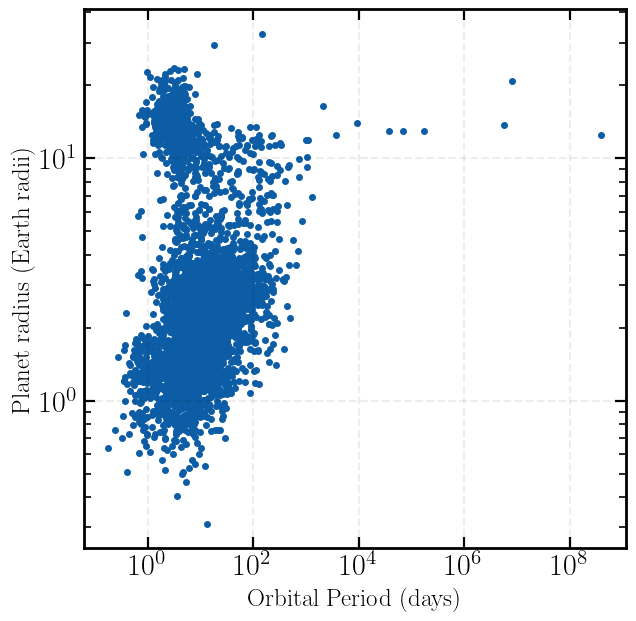

In [8]:
# First, we'll plot the orbital period of each planet ('pl_orbper') against its radius ('pl_rade')
plt.scatter(data['pl_orbper'], data['pl_rade']) # plot the data
# Label the axes
plt.xlabel('Orbital Period (days)')
plt.ylabel('Planet radius (Earth radii)')
# Change to log scales (because these numbers will cover a pretty large range)
plt.xscale('log')
plt.yscale('log')

This plot already tells us some interesting things. Fist, where does Earth fall on the plot? How do most observed exoplanet masses and periods compare to Earth? Try and add a special point on the plot to represent Earth! You might want to choose a different marker to represent that point -- see here: https://matplotlib.org/stable/api/markers_api.html

This time, try plotting mass against radius. You can check the list of column names here: https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html. 

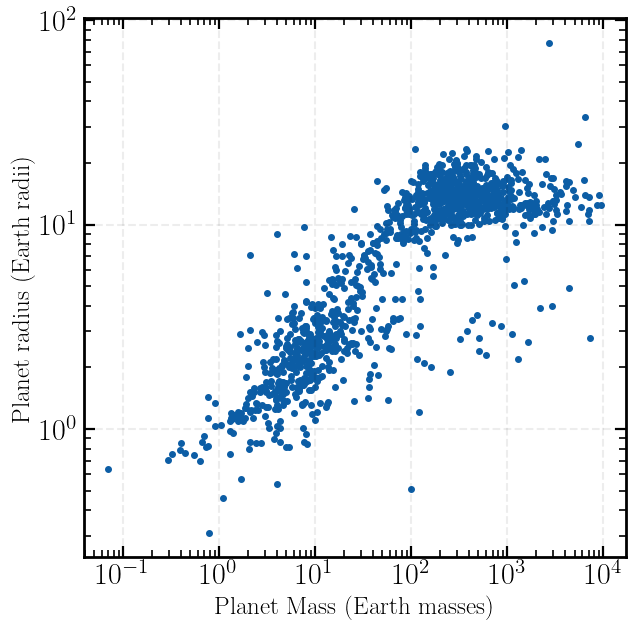

In [9]:
plt.scatter(data['pl_bmasse'], data['pl_rade']) # plot the data
# Label the axes
plt.xlabel('Planet Mass (Earth masses)')
plt.ylabel('Planet radius (Earth radii)')
# Change to log scales (because these numbers will cover a pretty large range)
plt.xscale('log')
plt.yscale('log')

## let's find life
Ok now let's try and use the equations you found before to identify which of these planets might be in the habitable zone of their stars. 

First, let's refresh our memory and make a function to turn orbital periods into the radius of the planet away from the star. The equation for this is $a = ( M * p^2 )^{1/3}$, where $a$ is the semimajor axis, $M$ is the mass of the host star in solar masses and $p$ is the period in years. The data table already gives us periods in years and star masses in solar masses, so we just need to read in those values, do the math in the equation above, and return distance $a$! Then, save those values into a new column in our data called 'pl_a'.

In [10]:
def calculate_a(M, p):
    return (M*p**2)**(1/3)

# Now test your function by applying it to the data table!
data['pl_a'] = calculate_a(data['st_mass'], data['pl_orbper'])

Now, let's make your equations into functions. For each, figure out what inputs you need, write out the equation for the temperature or distance to the planet, and then return the quantity. It is convenient to output distances from the star in AU, so check the units of your equation and make sure to add a conversion in your function if needed! It's good practice to note down the units for the inputs for your functions, so try and do that in the *docstrings*.

In [11]:
sigma_SB = 5.67e-5 # erg/cm^2/s/K^4
cm_in_AU = 1.5e13
Lsun_to_cgs = 4e33 # erg/s/Lsun

def T_planet(L, d):
    d_cgs = d * cm_in_AU
    L_cgs = L * Lsun_to_cgs
    return (L_cgs/16/np.pi/sigma_SB/d_cgs**2)**(1/4)

def d_planet(L, T):
    L_cgs = L * Lsun_to_cgs
    return np.sqrt(L_cgs/16/np.pi/sigma_SB/T**4) / cm_in_AU

Now let's test your functions! We'll use the Sun for this example. The temperature of the sun is 5800 K and the radius is $7 \times 10^{10}\ {\rm cm}$. What temperature would an earth-like planet have? (Earth has a radius of 6400 km and is at 1 AU, remember to convert your units!)

In [12]:
T_earth = T_planet(1, 1)
print(T_earth)
# The actual temperature of the Earth is aroudn 300 K. How does your answer compare? What might cause any differences between your calculation and the real value? 

# Given the temperature constraints you came up with for the habitable zone, use your calculator to get the inner and outer radii of the habitable zone
d_inner = d_planet(1, 370)
d_outer = d_planet(1, 270)
print(d_inner, d_outer)
# How do these distances compare with the solar system planets? 

281.03223660016306
0.5769110154016802 1.0833898217899867


### applying these functions to the exoplanet database
Let's go back to the data table we were looking at before! We're going to apply your calculator to every entry in the table. To make sure this will work, double check the column names you'll need to use and the units that each of those columns uses. You'll want the units to match those you wrote down in your calculator.  https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html

In [13]:
# First, let's make two new columns in the data table, one with the inner distance of the habitable zone and one with the outer. Fotr now we'll set both columns to 0
data['HZ_inner'] = np.zeros(len(data))
data['HZ_outer'] = np.zeros(len(data))

# While we're at it, let's make one more column that we'll use to mark down any planets within the habitable zone
data['planet_in_HZ'] = np.zeros(len(data))

Now we're going to use our function to fill in our two new columns! We need to tell python that we want the column 'HZ_inner' to be equal to the output of your d_planet function, using the appropriate columns as input. Which temperature for the planet do we want to input? Take a stab at writing this down as code, and ask for help if you get stuck! Then do the same thing for the 'HZ_outer' column. Which temperature do we want to use in this case? 

In [14]:
data['HZ_inner'] = d_planet(10**data['st_lum'], 373)
data['HZ_outer'] = d_planet(10**data['st_lum'], 273)

## Check for habitable zone planets
Now we want to go through our table and for each row, check whether the measured distance between the planet and star (semi-major axis) is within our inner and outer habitable zone bounds. Think about some of the stuff we've discussed in previous weeks and see if you can come up with a good way to do this! Ultimately, you'll want to set the value in the 'planet_in_HZ' column to be 1 if the planet is in the habitable zone, and 0 if not.

In [15]:
# In this cell, we want to write down code that will go through each line of the data table and check if the semi-major axis of the planet in that line is greater the our inner HZ bound and smaller than the outer bound
# If it is, set the column 'planet_in_HZ' to 1 for that row
# The structure of the code is outlined below, try to fill in the rest!

for pl in data.index: #this will loop through every planet in the index column of our data table
    if (data.loc[pl,'pl_a'] <= data.loc[pl,'HZ_outer'] and data.loc[pl,'pl_a'] >= data.loc[pl,'HZ_inner']):
        data.loc[pl,'planet_in_HZ'] = 1
    else:
        data.loc[pl,'planet_in_HZ'] = 0

How many of our planets are in the habitable zone?

In [16]:
sum(data['planet_in_HZ'])

33.0

Now let's plot the properties of these planets compared to the full distribution of observed exoplanets. You'll want to overlay this subset of the data on the full dataset from the plots we made before.

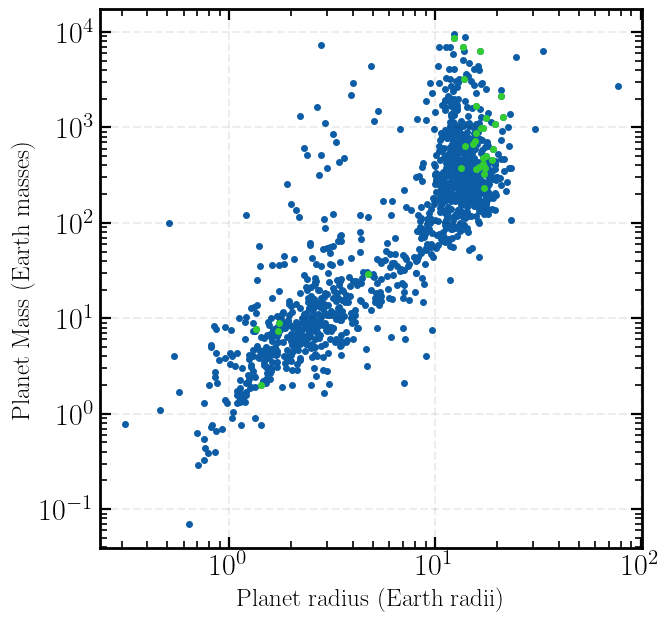

In [17]:
# First, we'll just collect the planets that were in the calculated habitable zones by selecting all the rows of the data table where 'planet_in_HZ' was set to 1:
data_HZ = data.loc[data['planet_in_HZ']==1]

# Now you can plot the planet properties in the data_HZ table! Take a look at the masses, radii, and periods like we did at the beginning of this notebook. 
plt.scatter(data['pl_rade'], data['pl_bmasse']) # plot the data
plt.scatter(data_HZ['pl_rade'], data_HZ['pl_bmasse'], color = 'limegreen') # plot the data
# Label the axes
plt.ylabel('Planet Mass (Earth masses)')
plt.xlabel('Planet radius (Earth radii)')
# Change to log scales (because these numbers will cover a pretty large range)
plt.xscale('log')
plt.yscale('log')

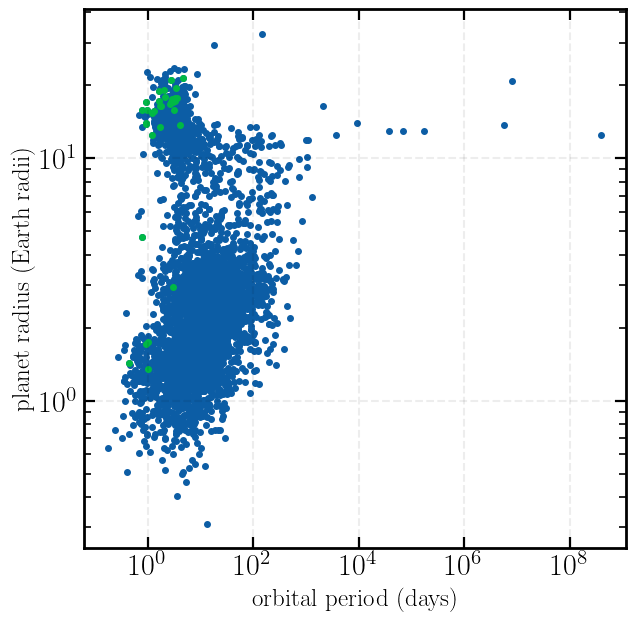

In [18]:
plt.scatter(data['pl_orbper'], data['pl_rade']) # plot the data
plt.scatter(data_HZ['pl_orbper'], data_HZ['pl_rade']) # plot the data
# Label the axes
plt.xlabel('orbital period (days)')
plt.ylabel('planet radius (Earth radii)')
# Change to log scales (because these numbers will cover a pretty large range)
plt.xscale('log')
plt.yscale('log')

## extra: where should we look for habitable zone planets?
As you've seen, the habitable zone depends on the properties of the host star. We classify stars into different types based on properties like temperature and color (https://www.britannica.com/science/stellar-classification). Using your data table, plot the range of the habitable zone against different stellar properties. To show the inner and outer limits of each star's zone, you can use the function plt.axvline(x, ymin, ymax), where ymin and ymax are the inner and outer radii of the zone and x is the value of the stellar property. Try a few different properties (temperature, radius, mass, luminosity) -- you can find a full list at this link, in the stellar properties table https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html. How do the habitable zones change with stellar properties? 

Let's also think about which habitable zones are the easiest to observe. You can read about different exoplanet detection methods [here](https://exoplanets.nasa.gov/alien-worlds/ways-to-find-a-planet/?intent=021). Which planets are easiest to detect? Based on this, what types of stars should we be targeting for habitable zone planet searches? 